In [1]:
import os

print(os.listdir("data"))

['Extended_Employee_Performance_and_Productivity_Data.csv.csv']


In [3]:
import pandas as pd

In [30]:
df = pd.read_csv("data/Extended_Employee_Performance_and_Productivity_Data.csv.csv")
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [34]:
df.shape

(100000, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

In [9]:
df.describe()

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


In [11]:
print("Total Employees:", len(df))

print("\nDepartments:")
print(df["Department"].value_counts())

print("\nAverage Performance Score:")
print(df["Performance_Score"].mean())

Total Employees: 100000

Departments:
Department
Marketing           11216
Finance             11200
Operations          11181
IT                  11131
Sales               11122
Legal               11118
Customer Support    11116
HR                  10960
Engineering         10956
Name: count, dtype: int64

Average Performance Score:
2.99543


In [13]:
department_perf = df.groupby("Department")["Performance_Score"].mean()

print(department_perf.sort_values(ascending=False))

Department
Engineering         3.020263
Operations          3.006797
IT                  3.000000
HR                  2.997354
Customer Support    2.997121
Sales               2.994336
Legal               2.981741
Finance             2.981161
Marketing           2.980653
Name: Performance_Score, dtype: float64


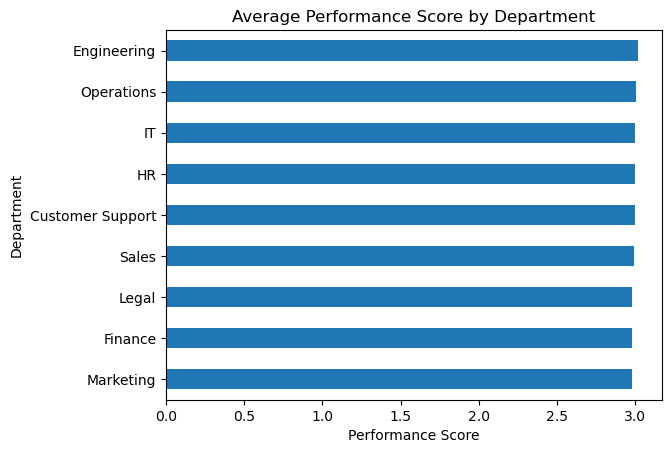

In [15]:
import matplotlib.pyplot as plt

department_perf.sort_values().plot(kind="barh")

plt.title("Average Performance Score by Department")
plt.xlabel("Performance Score")
plt.ylabel("Department")

plt.show()

In [16]:
salary_perf = df.groupby("Performance_Score")["Monthly_Salary"].mean()

print(salary_perf)

Performance_Score
1    5422.229125
2    5900.284815
3    6409.515476
4    6897.632899
5    7397.669109
Name: Monthly_Salary, dtype: float64


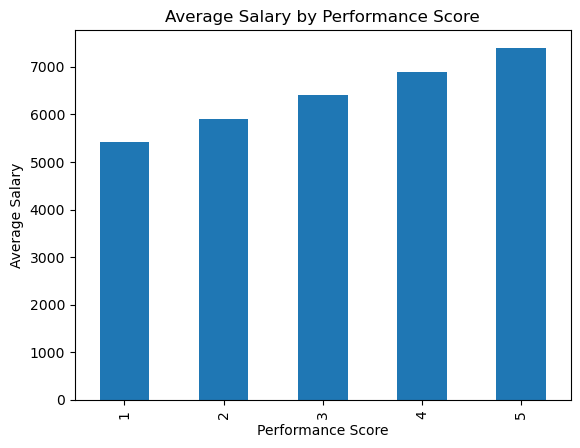

In [19]:
import matplotlib.pyplot as plt

salary_perf.plot(kind="bar")

plt.title("Average Salary by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Average Salary")

plt.show()

In [21]:
print("Duplicates:", df.duplicated().sum())

top10 = df.sort_values("Performance_Score", ascending=False).head(10)
top10[["Employee_ID","Department","Performance_Score","Monthly_Salary"]]

Duplicates: 0


,Employee_ID,Department,Performance_Score,Monthly_Salary
0,1,IT,5,6750.0
24362,24363,Marketing,5,9000.0
87690,87691,HR,5,6750.0
24384,24385,Engineering,5,5250.0
55688,55689,Legal,5,7500.0
24377,24378,Marketing,5,9000.0
55690,55691,Operations,5,5250.0
87693,87694,Sales,5,6000.0
87694,87695,Marketing,5,6000.0
87695,87696,HR,5,8250.0


In [24]:
# Top 10 Performers
top10 = df.sort_values(by="Performance_Score", ascending=False).head(10)

top10[["Employee_ID","Department","Performance_Score","Monthly_Salary"]]

,Employee_ID,Department,Performance_Score,Monthly_Salary
0,1,IT,5,6750.0
24362,24363,Marketing,5,9000.0
87690,87691,HR,5,6750.0
24384,24385,Engineering,5,5250.0
55688,55689,Legal,5,7500.0
24377,24378,Marketing,5,9000.0
55690,55691,Operations,5,5250.0
87693,87694,Sales,5,6000.0
87694,87695,Marketing,5,6000.0
87695,87696,HR,5,8250.0


In [26]:
# Department-wise Employee Count
df["Department"].value_counts()

Department
Marketing           11216
Finance             11200
Operations          11181
IT                  11131
Sales               11122
Legal               11118
Customer Support    11116
HR                  10960
Engineering         10956
Name: count, dtype: int64

In [28]:
# Average Salary by Department
df.groupby("Department")["Monthly_Salary"].mean().sort_values(ascending=False)

Department
Engineering         6417.246258
IT                  6414.598868
Sales               6413.154109
Operations          6412.306592
Customer Support    6403.881792
HR                  6400.355839
Finance             6398.575893
Legal               6391.275409
Marketing           6377.857525
Name: Monthly_Salary, dtype: float64